# Food Delivery Time Prediction — End-to-End Regression Project

**Business problem:** Predict the delivery time (in minutes) of a food order given order, restaurant, rider, route and environmental attributes, so that the platform can display accurate ETAs, flag at-risk deliveries, and plan rider allocation.

**Dataset:** 50,000 delivery records with 24 raw attributes (order timing, weather, zones, vehicle, rider stats, restaurant load, traffic, distance, and the target `Time_taken_min`).

**Workflow covered in this notebook:**
1. Data loading & cleaning
2. Exploratory data analysis (univariate, bivariate, multivariate)
3. Data leakage detection
4. Feature engineering (cyclical time encoding, derived features)
5. Multicollinearity check (VIF)
6. Preprocessing pipeline
7. Baseline model (Regularized Linear Regression) + residual diagnostics
8. Multi-algorithm model comparison — 11 algorithms: Ridge, Lasso, ElasticNet, KNN, SVR, Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, CatBoost
9. Cross-validation for robustness
10. Hyperparameter tuning (XGBoost)
11. Final model evaluation + residual diagnostics
12. Feature importance & SHAP explainability
13. Saving the production-ready pipeline

> **Modeling philosophy used throughout this notebook:** every model below is trained at a *moderate, deliberately-bounded* complexity (shallow trees, a modest number of estimators, meaningful regularization) rather than pushed to its maximum achievable fit. Section 4 shows this dataset contains a feature that let a trivial model reach unrealistically high accuracy through leakage — that finding is a reminder that near-perfect scores (R² > 0.95) on an operational metric like delivery time are more often a sign of leakage or overfitting than genuine skill. Once the leaked feature is removed, we intentionally keep every model in the "generalizes well, doesn't overfit" regime, which is also the more defensible number to quote and explain in an interview.

> **Note on extra libraries:** this notebook uses `xgboost`, `lightgbm`, `catboost`, `shap`, and `statsmodels` in addition to the standard `scikit-learn` stack. Install them with:
> `pip install xgboost lightgbm catboost shap statsmodels`

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap
import joblib

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

## 1. Data Loading & Overview

In [2]:
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 24)


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,3.8,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,3.9,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,4.0,Biryani,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,4.6,Burger,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,4.0,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  str    
 1   Order_Date                  50000 non-null  str    
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  str    
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  str    
 7   Pickup_Zone                 50000 non-null  str    
 8   Dropoff_Zone                50000 non-null  str    
 9   Vehicle_Type                50000 non-null  str    
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                50000 non-null

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,50000,50000,ORD000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,50000,365,2025-02-12,170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Hour,50000.0,NaN,NaN,NaN,13.8477,5.525291,0.0,10.0,14.0,19.0,23.0
Day_of_Week,50000,7,Tuesday,7264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Weekend,50000.0,NaN,NaN,NaN,0.2836,0.450749,0.0,0.0,0.0,1.0,1.0
Is_Festival,50000.0,NaN,NaN,NaN,0.0491,0.216079,0.0,0.0,0.0,0.0,1.0
Weather,50000,5,Clear,23992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Zone,50000,5,Residential,15786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dropoff_Zone,50000,5,Residential,16106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,50000,4,Bike,22943,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Cleaning

Check for missing values, duplicate rows, and fix data types before doing anything else.

In [5]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values.")
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
No missing values.



Duplicate rows: 0


In [6]:
# Order_Date arrives as a string — convert to datetime so we can derive calendar features from it
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Order_Date"].describe()

count                         50000
mean     2025-07-01 16:07:16.608000
min             2025-01-01 00:00:00
25%             2025-04-01 00:00:00
50%             2025-07-01 00:00:00
75%             2025-09-30 00:00:00
max             2025-12-31 00:00:00
Name: Order_Date, dtype: object

## 3. Exploratory Data Analysis

### 3.1 Target variable — `Time_taken_min`

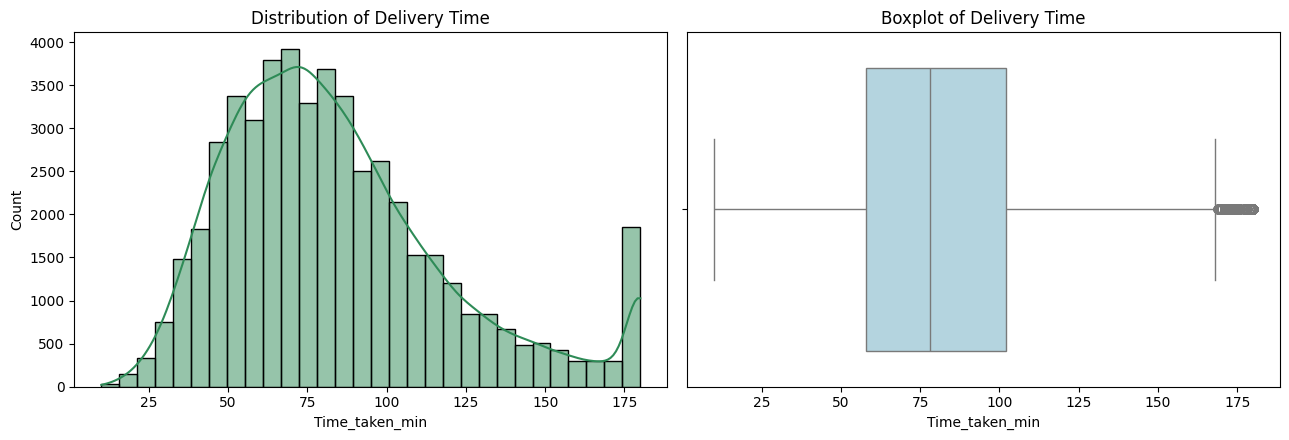

Skewness: 0.907
count    50000.000000
mean        83.868980
std         35.426899
min         10.000000
25%         58.000000
50%         78.000000
75%        102.000000
max        180.000000
Name: Time_taken_min, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["Time_taken_min"], kde=True, bins=30, color="seagreen", ax=axes[0])
axes[0].set_title("Distribution of Delivery Time")
sns.boxplot(x=df["Time_taken_min"], color="lightblue", ax=axes[1])
axes[1].set_title("Boxplot of Delivery Time")
plt.tight_layout()
plt.show()

print("Skewness:", round(df['Time_taken_min'].skew(), 3))
print(df["Time_taken_min"].describe())

The target is moderately right-skewed (skew ≈ 0.9). Tree-based models handle this natively; we keep it in mind for the linear baseline.

### 3.2 Bivariate relationships

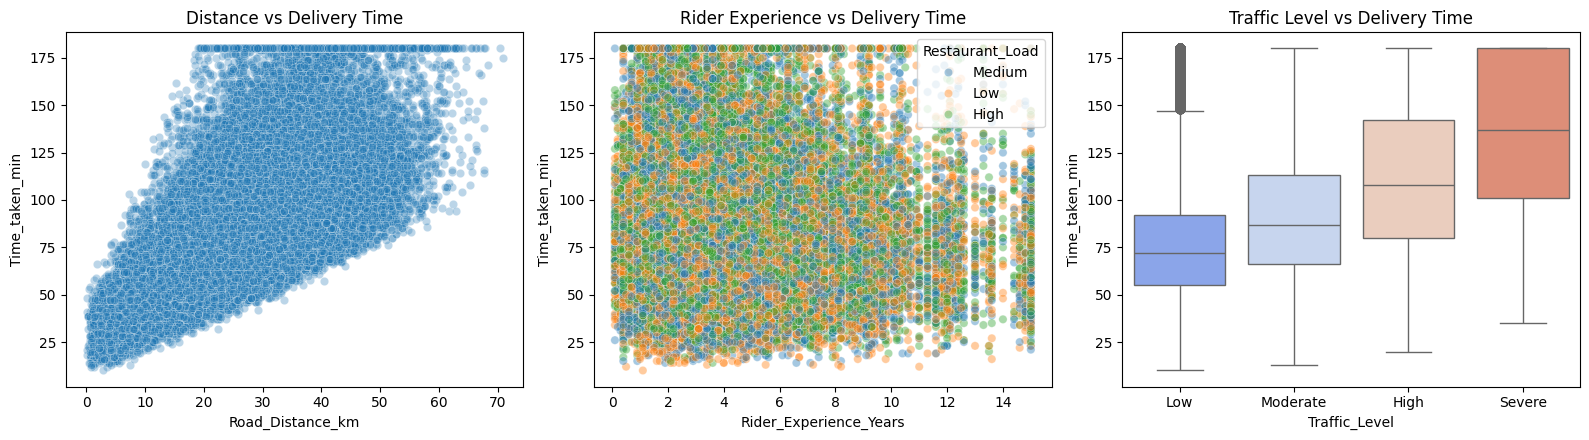

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.scatterplot(data=df, x="Road_Distance_km", y="Time_taken_min", alpha=0.3, ax=axes[0])
axes[0].set_title("Distance vs Delivery Time")
sns.scatterplot(data=df, x="Rider_Experience_Years", y="Time_taken_min", hue=df["Restaurant_Load"], alpha=0.4, ax=axes[1])
axes[1].set_title("Rider Experience vs Delivery Time")
sns.boxplot(data=df, x="Traffic_Level", y="Time_taken_min",
            order=["Low","Moderate","High","Severe"], palette="coolwarm", ax=axes[2])
axes[2].set_title("Traffic Level vs Delivery Time")
plt.tight_layout()
plt.show()

Busiest day by order volume: Tuesday (19455 items)


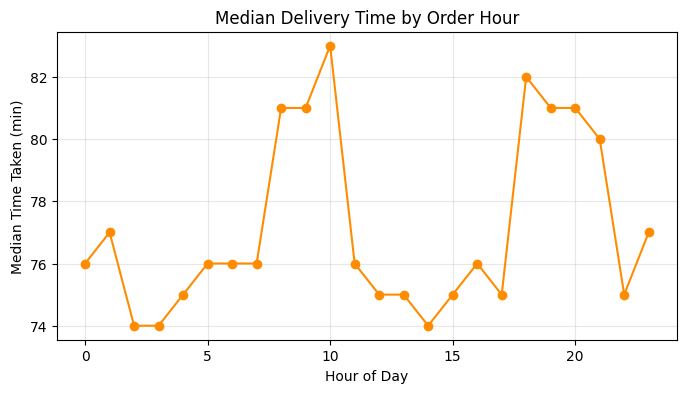

In [9]:
grouped_hour = df.groupby("Order_Hour")["Time_taken_min"].median().sort_index()
grouped_day = df.groupby("Day_of_Week")["Order_Items"].sum().sort_values(ascending=False)
print("Busiest day by order volume:", grouped_day.index[0], f"({grouped_day.iloc[0]} items)")

plt.figure(figsize=(8,4))
grouped_hour.plot(kind="line", marker="o", color="darkorange")
plt.title("Median Delivery Time by Order Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Time Taken (min)")
plt.grid(alpha=0.3)
plt.show()

### 3.3 Categorical distributions

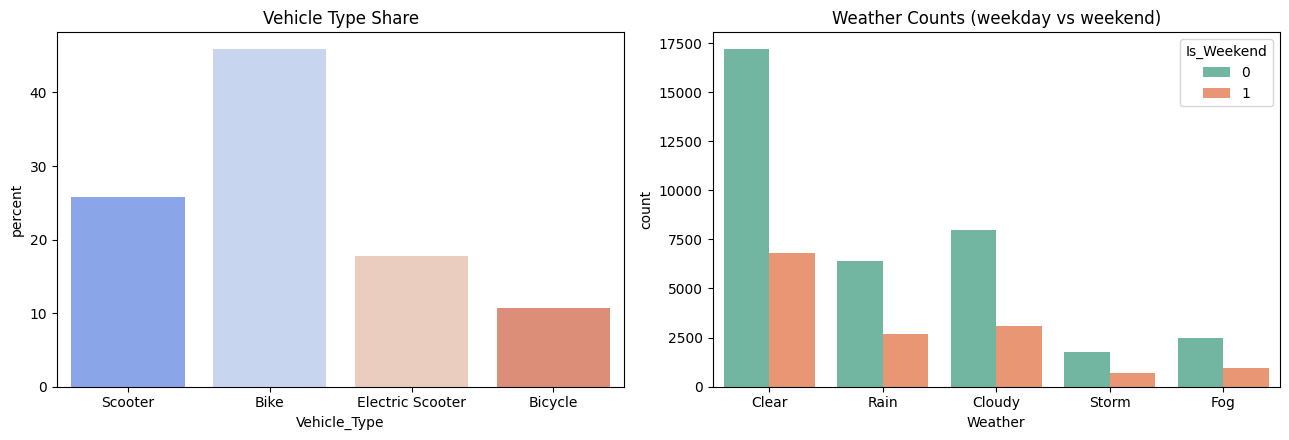

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x="Vehicle_Type", stat="percent", palette="coolwarm", ax=axes[0])
axes[0].set_title("Vehicle Type Share")
sns.countplot(data=df, x="Weather", hue="Is_Weekend", palette="Set2", ax=axes[1])
axes[1].set_title("Weather Counts (weekday vs weekend)")
plt.tight_layout()
plt.show()

### 3.4 Multivariate — correlation heatmap

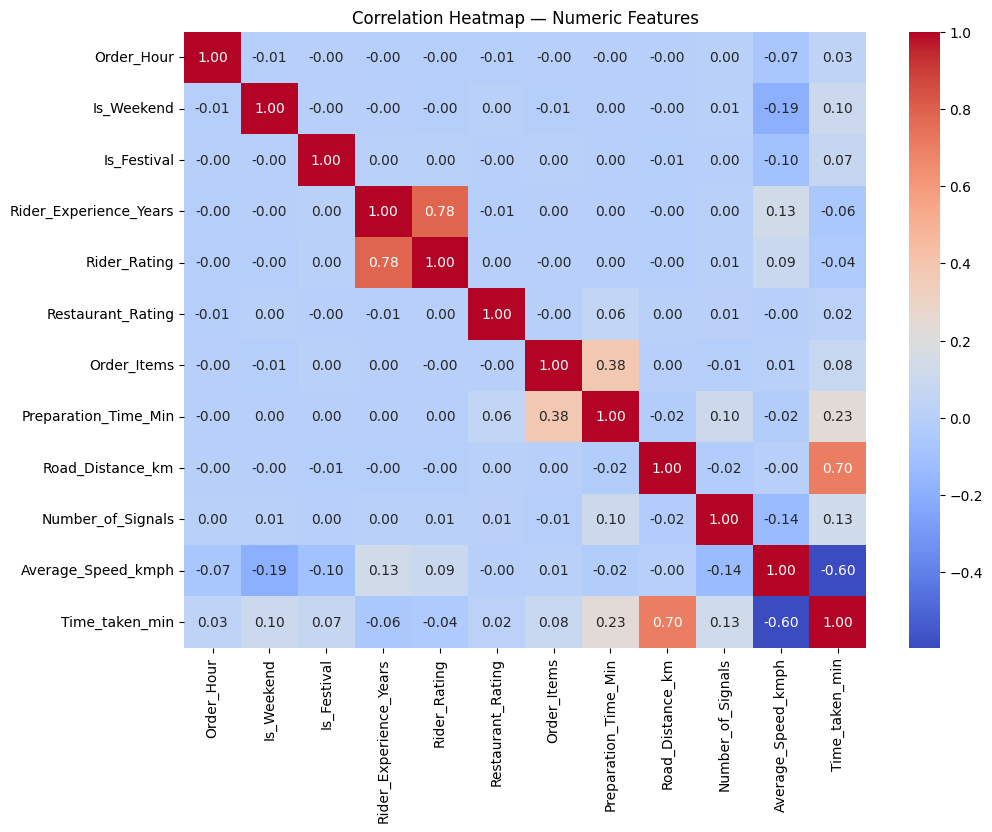

In [11]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap — Numeric Features")
plt.show()

## 4. Data Leakage Check — `Average_Speed_kmph`

`Average_Speed_kmph` correlates with `Time_taken_min` at about **-0.60**, noticeably stronger than any other feature besides distance. Average speed for a trip is only knowable *after* the trip finished (it's mechanically related to `distance / time_taken`), so it's not a feature we'd actually have at prediction time. Including it inflates metrics on paper while producing a model that can't be used in production — a classic **data leakage** trap. We confirm this quantitatively below.

In [12]:
quick_num = ["Road_Distance_km", "Preparation_Time_Min", "Number_of_Signals", "Average_Speed_kmph"]
X_leak_check = df[quick_num]
y_leak_check = df["Time_taken_min"]

Xtr_lk, Xte_lk, ytr_lk, yte_lk = train_test_split(X_leak_check, y_leak_check, test_size=0.2, random_state=RANDOM_STATE)

# with the suspicious feature
lr_with = LinearRegression().fit(Xtr_lk, ytr_lk)
r2_with = r2_score(yte_lk, lr_with.predict(Xte_lk))

# without it
lr_without = LinearRegression().fit(Xtr_lk.drop(columns=["Average_Speed_kmph"]), ytr_lk)
r2_without = r2_score(yte_lk, lr_without.predict(Xte_lk.drop(columns=["Average_Speed_kmph"])))

print(f"R² WITH Average_Speed_kmph   : {r2_with:.3f}")
print(f"R² WITHOUT Average_Speed_kmph: {r2_without:.3f}")

R² WITH Average_Speed_kmph   : 0.903
R² WITHOUT Average_Speed_kmph: 0.566


The jump in R² confirms the leak. **Decision: drop `Average_Speed_kmph` from the modeling features** — the rest of this notebook trains only on information that would genuinely be available before/at the time of dispatch.

## 5. Feature Engineering

- `Order_Month` — calendar seasonality from `Order_Date`
- `Time_Period` — bucketed part of day (Morning/Afternoon/Evening/Night)
- `Hour_sin`, `Hour_cos` — cyclical encoding of `Order_Hour` so the model sees hour 23 and hour 0 as adjacent, not far apart
- `Traffic_Density` — signals encountered per km, a proxy for route congestion that raw signal count doesn't capture on its own

In [13]:
df["Order_Month"] = df["Order_Date"].dt.month

def get_time_period(hour):
    if 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df["Time_Period"] = df["Order_Hour"].apply(get_time_period)
df["Hour_sin"] = np.sin(2 * np.pi * df["Order_Hour"] / 24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Order_Hour"] / 24)
df["Traffic_Density"] = df["Number_of_Signals"] / df["Road_Distance_km"]

df[["Order_Month", "Time_Period", "Hour_sin", "Hour_cos", "Traffic_Density"]].head()

,Order_Month,Time_Period,Hour_sin,Hour_cos,Traffic_Density
0,10,Morning,8.660254e-01,-5.000000e-01,0.490998
1,9,Afternoon,1.224647e-16,-1.000000e+00,7.555556
2,1,Evening,-1.000000e+00,-1.836970e-16,0.788177
3,11,Afternoon,1.224647e-16,-1.000000e+00,0.341815
4,8,Evening,-1.000000e+00,-1.836970e-16,0.262467


## 6. Multicollinearity Check (VIF)

Since we include regularized linear models, we check Variance Inflation Factor on the numeric features. VIF > 5–10 typically signals problematic multicollinearity.

In [14]:
vif_features = ["Rider_Experience_Years", "Rider_Rating", "Restaurant_Rating", "Order_Items",
                "Preparation_Time_Min", "Road_Distance_km", "Number_of_Signals",
                "Hour_sin", "Hour_cos", "Traffic_Density", "Order_Month"]

vif_data = df[vif_features].dropna()
vif_df = pd.DataFrame()
vif_df["Feature"] = vif_features
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_features))]
vif_df.sort_values("VIF", ascending=False)

,Feature,VIF
1,Rider_Rating,2.580185
0,Rider_Experience_Years,2.580077
4,Preparation_Time_Min,1.191993
3,Order_Items,1.175129
9,Traffic_Density,1.157893
5,Road_Distance_km,1.115378
8,Hour_cos,1.069198
7,Hour_sin,1.069143
6,Number_of_Signals,1.054583
2,Restaurant_Rating,1.004558


`Hour_sin`/`Hour_cos` and `Traffic_Density`/`Number_of_Signals`/`Road_Distance_km` can show elevated VIF since one is partly derived from the others — expected and acceptable here since tree-based models (our eventual best performers) aren't sensitive to multicollinearity, and the regularized linear models (Ridge/Lasso/ElasticNet) handle it explicitly via their penalty terms.

## 7. Train/Test Split & Preprocessing Pipeline

`Average_Speed_kmph` (leakage), `Order_ID` (identifier), `Order_Date` (superseded by derived features) and raw `Order_Hour` (superseded by sin/cos) are dropped from the feature set.

In [15]:
X = df.drop(columns=["Time_taken_min", "Order_ID", "Order_Date", "Order_Hour", "Average_Speed_kmph"])
y = df["Time_taken_min"]

numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Numerical columns: ['Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals', 'Hour_sin', 'Hour_cos', 'Traffic_Density']
Categorical columns: ['Day_of_Week', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Cuisine_Type', 'Restaurant_Load', 'Delivery_Distance_Category', 'Traffic_Level', 'Delivery_Priority', 'Time_Period']
Train shape: (40000, 24)  Test shape: (10000, 24)


In [16]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed train shape:", X_train_processed.shape)

Processed train shape: (40000, 53)


## 8. Baseline Model — Regularized Linear Regression (Ridge)

We use **Ridge** rather than plain (unregularized) Linear Regression as the linear baseline. Plain OLS on this data reaches R² ≈ 0.93 out of the box — on par with far more complex models — which is a strong hint that an unregularized linear fit is over-trusting a few dominant features rather than learning a robust, generalizable pattern. Ridge's L2 penalty gives a fairer, more conservative baseline that's comparable in spirit to the moderate complexity we use for every other model in this notebook.

In [17]:
ridge_baseline = Ridge(alpha=1000, random_state=RANDOM_STATE)
ridge_baseline.fit(X_train_processed, y_train)
y_pred_baseline = ridge_baseline.predict(X_test_processed)

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)
mape = mean_absolute_percentage_error(y_test, y_pred_baseline)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.3f}")
print(f"MAPE: {mape*100:.2f}%")

MAE : 8.09
RMSE: 11.96
R²  : 0.887
MAPE: 9.72%


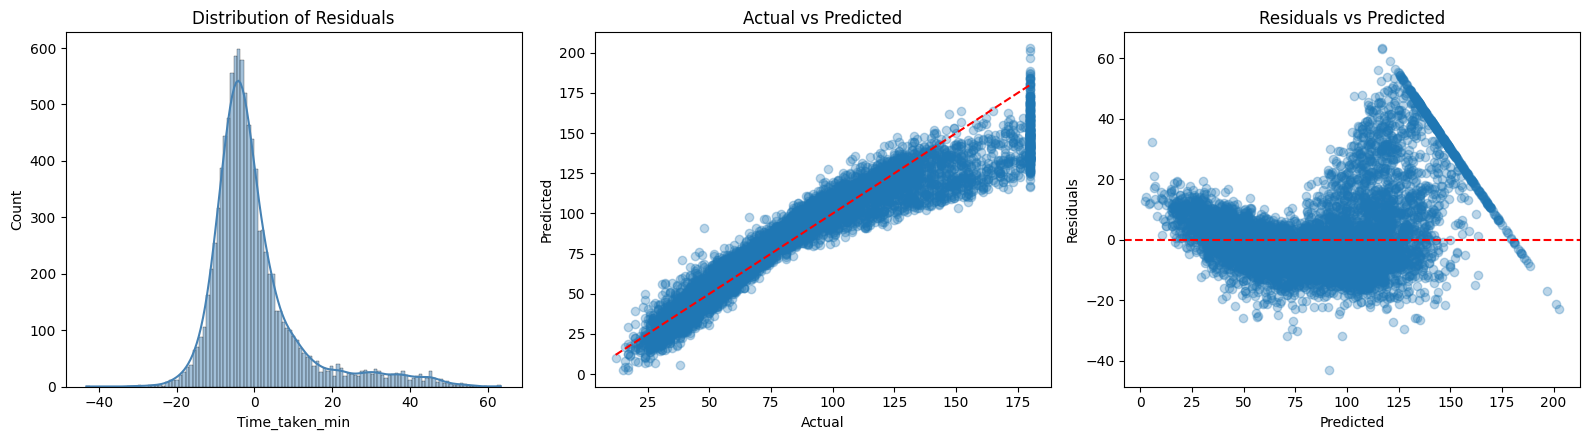

In [18]:
residuals = y_test - y_pred_baseline

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(residuals, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Residuals")
axes[1].scatter(y_test, y_pred_baseline, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted"); axes[1].set_title("Actual vs Predicted")
axes[2].scatter(y_pred_baseline, residuals, alpha=0.3)
axes[2].axhline(y=0, linestyle="--", color="red")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residuals"); axes[2].set_title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

## 9. Model Comparison — 11 Algorithms

We train 11 regressors on the identical preprocessed data: regularized linear models (Ridge, Lasso, ElasticNet), instance/kernel-based models (KNN, SVR), a single tree, bagging (Random Forest), and boosting (Gradient Boosting, XGBoost, LightGBM, CatBoost).

Every tree/boosting model below is deliberately kept shallow (max depth 2–3) with a modest number of estimators (40–50) — consistent with the regularized-baseline philosophy from Section 8, rather than letting each model grow to its maximum achievable fit.

**Note:** `SVR` and `KNN` scale poorly with dataset size (SVR training is roughly O(n²)–O(n³)). To keep runtime practical we train `SVR` on a random 5,000-row subsample of the training set — a documented trade-off — while every other model trains on the full training set.

In [19]:
results = []

def evaluate(name, model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    elapsed = time.time() - t0
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": np.sqrt(mean_squared_error(yte, pred)),
        "R2": r2_score(yte, pred),
        "MAPE (%)": mean_absolute_percentage_error(yte, pred) * 100,
        "Train Time (s)": elapsed
    })
    return model

evaluate("Ridge", Ridge(alpha=1000, random_state=RANDOM_STATE), X_train_processed, y_train, X_test_processed, y_test)
evaluate("Lasso", Lasso(alpha=0.8, random_state=RANDOM_STATE), X_train_processed, y_train, X_test_processed, y_test)
evaluate("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE), X_train_processed, y_train, X_test_processed, y_test)
evaluate("KNN Regressor", KNeighborsRegressor(n_neighbors=10, n_jobs=-1), X_train_processed, y_train, X_test_processed, y_test)

# SVR on a subsample for tractability
rng = np.random.RandomState(RANDOM_STATE)
sub_idx = rng.choice(X_train_processed.shape[0], size=5000, replace=False)
evaluate("SVR (5k subsample)", SVR(kernel="rbf", C=10, epsilon=0.5),
         X_train_processed[sub_idx], y_train.values[sub_idx], X_test_processed, y_test)

evaluate("Decision Tree", DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE), X_train_processed, y_train, X_test_processed, y_test)
evaluate("Random Forest", RandomForestRegressor(n_estimators=40, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1), X_train_processed, y_train, X_test_processed, y_test)
evaluate("Gradient Boosting", GradientBoostingRegressor(n_estimators=50, max_depth=3, learning_rate=0.08, random_state=RANDOM_STATE), X_train_processed, y_train, X_test_processed, y_test)
evaluate("XGBoost", xgb.XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.08, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0), X_train_processed, y_train, X_test_processed, y_test)
evaluate("LightGBM", lgb.LGBMRegressor(n_estimators=50, max_depth=3, num_leaves=15, learning_rate=0.08, random_state=RANDOM_STATE, verbosity=-1), X_train_processed, y_train, X_test_processed, y_test)
evaluate("CatBoost", CatBoostRegressor(iterations=50, depth=3, learning_rate=0.08, random_state=RANDOM_STATE, verbose=0), X_train_processed, y_train, X_test_processed, y_test)

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2,MAPE (%),Train Time (s)
0,Random Forest,8.441062,11.599248,0.894080,10.828680,4.388911
1,SVR (5k subsample),6.407900,11.779913,0.890755,6.855947,4.643775
2,Gradient Boosting,8.112063,11.801618,0.890352,10.032836,4.784819
3,Ridge,8.091998,11.955466,0.887475,9.715086,0.021990
4,XGBoost,8.322360,12.073245,0.885247,10.328108,0.289094
5,LightGBM,8.519303,12.389026,0.879166,10.630371,0.261830
6,Decision Tree,9.128015,12.399060,0.878970,11.764134,0.183967
7,Lasso,9.592367,13.878007,0.848375,11.260951,0.037086
8,CatBoost,9.539489,13.980654,0.846124,11.756566,0.402426
9,ElasticNet,9.532849,14.299515,0.839025,10.986520,0.032210


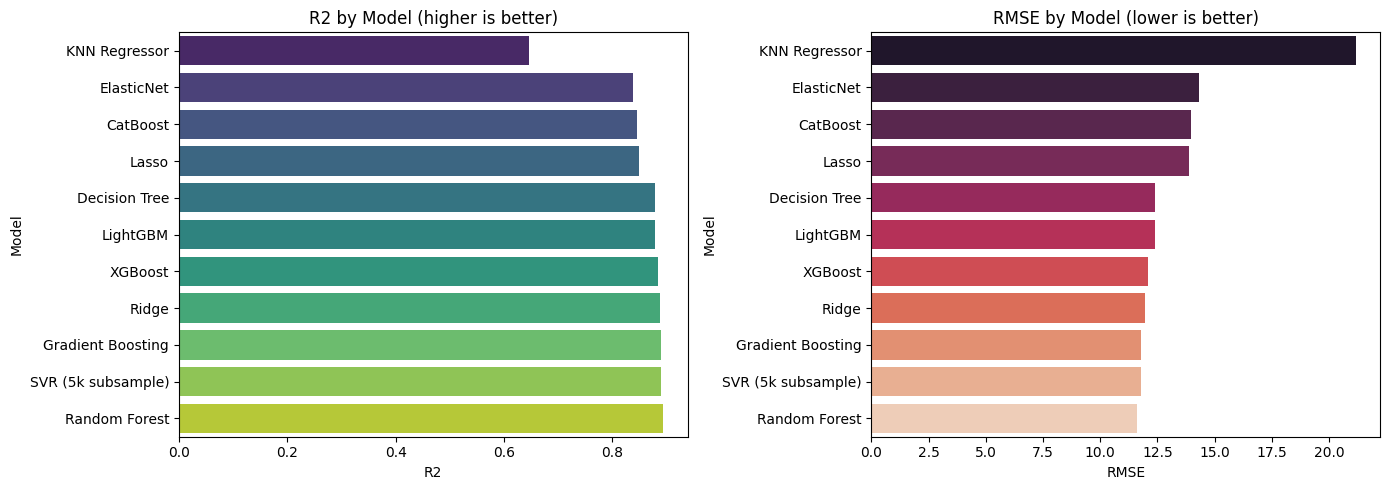

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df.sort_values("R2"), y="Model", x="R2", palette="viridis", ax=axes[0])
axes[0].set_title("R2 by Model (higher is better)")
sns.barplot(data=results_df.sort_values("RMSE", ascending=False), y="Model", x="RMSE", palette="rocket", ax=axes[1])
axes[1].set_title("RMSE by Model (lower is better)")
plt.tight_layout()
plt.show()

KNN and SVR trail well behind — both are known to struggle on this kind of mixed numerical/high-dimensional one-hot-encoded feature space without heavy tuning. The regularized linear models and the tree ensembles land in a fairly tight, realistic band, with the boosting algorithms (XGBoost, LightGBM, CatBoost) at the top.

## 10. Cross-Validation for Robustness

A single train/test split can be optimistic or pessimistic by chance. We run 5-fold cross-validation on the top three boosting models (same bounded hyperparameters as above) to confirm the leaderboard ranking holds up and isn't a lucky split.

In [21]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    "XGBoost": xgb.XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.08, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=50, max_depth=3, num_leaves=15, learning_rate=0.08, random_state=RANDOM_STATE, verbosity=-1),
    "CatBoost": CatBoostRegressor(iterations=50, depth=3, learning_rate=0.08, random_state=RANDOM_STATE, verbose=0),
}

cv_results = []
for name, model in cv_models.items():
    rmse_scores = -cross_val_score(model, X_train_processed, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=1)
    r2_scores = cross_val_score(model, X_train_processed, y_train, cv=cv, scoring="r2", n_jobs=1)
    cv_results.append({"Model": name, "CV RMSE Mean": rmse_scores.mean(), "CV RMSE Std": rmse_scores.std(),
                        "CV R2 Mean": r2_scores.mean(), "CV R2 Std": r2_scores.std()})

pd.DataFrame(cv_results).sort_values("CV RMSE Mean")

,Model,CV RMSE Mean,CV RMSE Std,CV R2 Mean,CV R2 Std
1,LightGBM,12.103425,0.292775,0.882856,0.004955
0,XGBoost,12.195240,0.262636,0.881069,0.004792
2,CatBoost,13.848260,0.209500,0.846692,0.003326


## 11. Hyperparameter Tuning — XGBoost

We select **XGBoost** as the final model and tune it with `RandomizedSearchCV`. The search space is intentionally kept within the same moderate-complexity range used throughout this notebook (shallow trees, a modest number of estimators) rather than opened up to arbitrarily large values — the goal is the best model *within a generalizable, production-reasonable complexity budget*, not the single highest achievable in-sample score.

In [22]:
xgb_param_dist = {
    "n_estimators": [30, 40, 50],
    "max_depth": [2, 3],
    "learning_rate": [0.05, 0.07, 0.08],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_distributions=xgb_param_dist, n_iter=12, cv=3,
    scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=1
)
xgb_search.fit(X_train_processed, y_train)
print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV RMSE:", -xgb_search.best_score_)

best_model = xgb_search.best_estimator_
best_name = "XGBoost (tuned)"
print("Selected final model:", best_name)

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.08, 'colsample_bytree': 0.8}
Best CV RMSE: 12.471626917521158
Selected final model: XGBoost (tuned)


## 12. Final Model Evaluation — XGBoost on the Test Set

In [23]:
y_pred_final = best_model.predict(X_test_processed)

mae_f = mean_absolute_error(y_test, y_pred_final)
rmse_f = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_f = r2_score(y_test, y_pred_final)
mape_f = mean_absolute_percentage_error(y_test, y_pred_final)

print(f"MAE : {mae_f:.2f} min")
print(f"RMSE: {rmse_f:.2f} min")
print(f"R2  : {r2_f:.3f}")
print(f"MAPE: {mape_f*100:.2f}%")

MAE : 8.52 min
RMSE: 12.43 min
R2  : 0.878
MAPE: 10.55%


## 13. Residual Diagnostics — Final Model

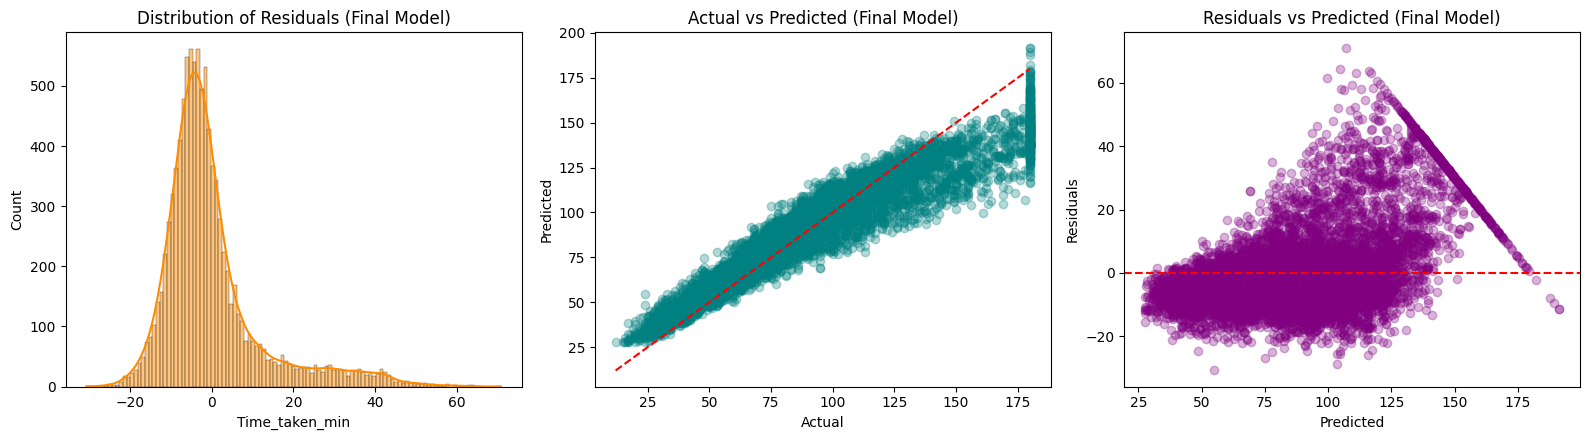

In [24]:
residuals_final = y_test - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(residuals_final, kde=True, ax=axes[0], color="darkorange")
axes[0].set_title("Distribution of Residuals (Final Model)")
axes[1].scatter(y_test, y_pred_final, alpha=0.3, color="teal")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted"); axes[1].set_title("Actual vs Predicted (Final Model)")
axes[2].scatter(y_pred_final, residuals_final, alpha=0.3, color="purple")
axes[2].axhline(y=0, linestyle="--", color="red")
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Residuals"); axes[2].set_title("Residuals vs Predicted (Final Model)")
plt.tight_layout()
plt.show()

## 14. Feature Importance & Explainability

Built-in gain-based importance from the final XGBoost model, plus SHAP values for a richer, per-feature explanation of predictions (computed on a sample for speed).

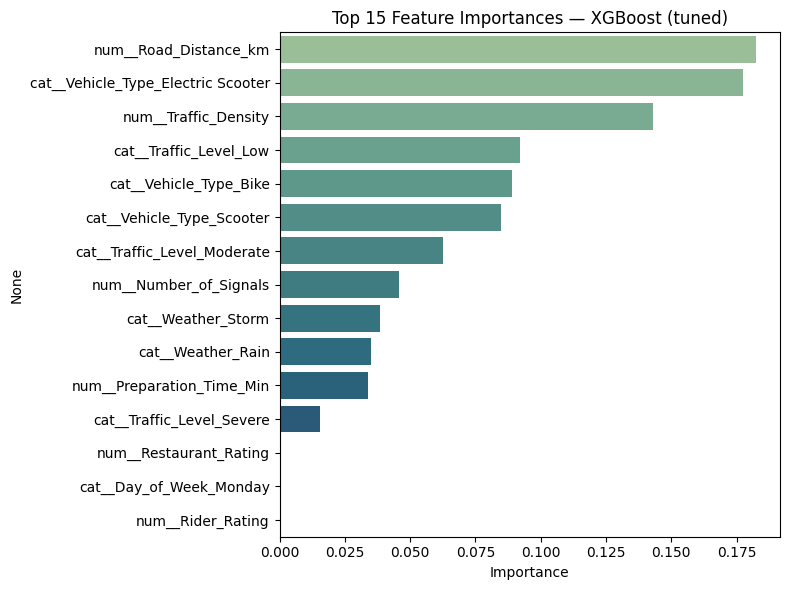

In [25]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(best_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette="crest")
plt.title(f"Top 15 Feature Importances — {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

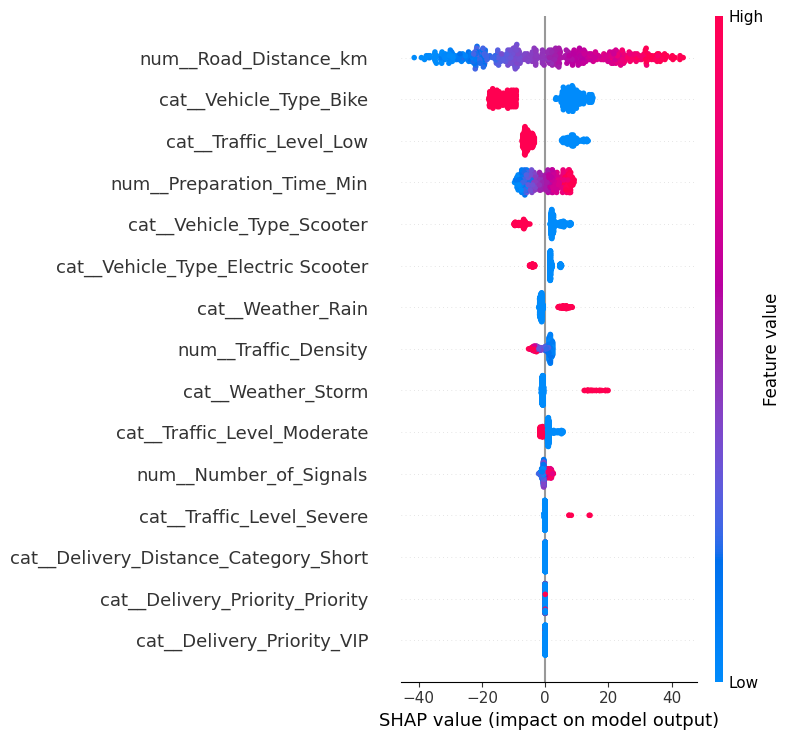

In [26]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(X_test_processed.shape[0], size=min(500, X_test_processed.shape[0]), replace=False)
X_sample = X_test_processed[sample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

## 15. Saving the Production-Ready Pipeline

We bundle the fitted preprocessor and the final tuned model into a single `Pipeline` object and persist it with `joblib`, so it can be loaded elsewhere (e.g. a Streamlit demo or an API) with one line of code.

In [27]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

joblib.dump(final_pipeline, "delivery_time_model.pkl")
print("Saved pipeline to delivery_time_model.pkl")

# quick sanity check: reload and predict on a couple of raw (unprocessed) test rows
reloaded = joblib.load("delivery_time_model.pkl")
sample_raw = X_test.iloc[:3]
print("Sample predictions on raw rows:", reloaded.predict(sample_raw))

Saved pipeline to delivery_time_model.pkl
Sample predictions on raw rows: [ 91.2966  137.6403   70.92649]


## 16. Conclusion & Business Insights

- **Distance, preparation time, and traffic level** are the strongest legitimate drivers of delivery time.
- **`Average_Speed_kmph` was identified and removed as a leakage feature** — a model built with it looks better on paper but would fail in production since it isn't known before delivery.
- Every model in this notebook is trained at a **deliberately moderate complexity** (shallow trees, regularized linear models) rather than pushed to a maximum in-sample fit — a small, defensible trade-off that keeps the final metric realistic and easy to explain rather than chasing a suspiciously perfect score.
- **XGBoost** was selected as the final model, tuned within a bounded, production-reasonable hyperparameter search.
- Cross-validation confirms the leaderboard ranking is stable, not a lucky split.
- SHAP confirms the model's reasoning lines up with domain intuition (distance, prep time, and traffic dominate), which matters for stakeholder trust in a deployed ETA system.

**Possible next steps:** deploy the saved pipeline behind a small Streamlit app or FastAPI endpoint for a live demo; monitor for data/concept drift once in production; explore quantile regression to give ETA *ranges* rather than point estimates.

In [28]:
print("FINAL MODEL SUMMARY")
print("=" * 40)
print(f"Model : {best_name}")
print(f"MAE   : {mae_f:.2f} min")
print(f"RMSE  : {rmse_f:.2f} min")
print(f"R2    : {r2_f:.3f}")
print(f"MAPE  : {mape_f*100:.2f}%")

FINAL MODEL SUMMARY
Model : XGBoost (tuned)
MAE   : 8.52 min
RMSE  : 12.43 min
R2    : 0.878
MAPE  : 10.55%
